# Preparing Real Observations

Turn real Argo profiles from CrocoLake into DART `obs_seq` files for your regional
MOM6 domain!

A typical observation-preparation workflow consists of these steps:

1. Define your experiment parameters: what observations do you need and when?
2. Generate `obs_seq` files from CrocoLake.
3. Inspect the result with pyDARTdiags.

*This is Part 1 of the DART tutorial series:*  
**1. Working with Real Observations** ·
[2. Creating Synthetic Observations](tutorial2_synthetic_observations.ipynb) ·
[3. Cycling DART–CESM](tutorial3_cycling_dart_cesm.ipynb)

```{admonition} What you'll learn
:class: tip

- How DART ingests observations: one `obs_seq` file per assimilation window
- What an observation is to DART: type, location, vertical coordinate, value, error variance, time and sometimes additional metadata
- How to pull real ocean observations from CrocoLake with `dartobsgen`
- Why observations must match your model domain and your experiment time frame
```

```{admonition} What you'll produce
:class: important

A directory `obs/real/ocn_obs_seq` containing 3 `obs_seq` files. The files will contain Argo temperature 
and salinity observations from 2023-06-15 to  2023-06-18 for the Hawaii domain. 
```


## Before you start

You need:

- **Access to Derecho** (or an equivalent HPC system)
- The [crocodile2026 workspace](https://github.com/CROCODILE-CESM/CROCODILEWorkspace) installed. We'll assume you have installed
  the workspace to /glade/work/$USER/crocodile2026.
- **CROCOLAKE** the observational database.
- Select the  **CESM_DA conda environment** as the kernel for the DA tutorial notebooks.

- A **DART clone** to use DART's CrocoLake observation converter:

  For the CROODILE Workshop you can use the DART and CROCOLAKE provided on glade.

  If you're following this tutorial using a machine other than Derecho or Casper, you can
  [download DART](https://docs.dart.ucar.edu/en/latest/guide/downloading-dart.html) from [GitHub](https://github.com/NCAR/DART.git) and download [CrocoLake](https://crocolakedocs.readthedocs.io/en/latest/crocolake.html#crocolake) directly.



# SECTION 1: How DART sees an observation

## Step 1.1: Anatomy of an obs_seq file

DART does not read observations from netCDF, CSV, or parquet. It reads its own 
**observation sequence** (`obs_seq`) format. Every observation in an `obs_seq` file has these
five pieces of information:

| Field | Meaning |
|---|---|
| **type** | What was measured and by what platform, e.g. `ARGO_TEMPERATURE` |
| **location** | Longitude, latitude (stored in radians) and a vertical coordinate |
| **value** | The measured value |
| **error variance** | How much you trust the measurement (instrument + representativeness error, squared) |
| **time** | Days and seconds since the DART epoch, 1601-01-01 |

Here is one observation from an obs_seq file, annotated:

```text
 OBS            1
   28.618                        <-- observation value (e.g. Temp in degrees C)
   0.0000                        <-- quality control flag
          -1         2        -1 <-- linked list bookkeeping (ignore)
obdef
loc3d
   0.858377  0.141890   10.0  3  <-- lon (rad), lat (rad), vertical, vertical coord type
kind
          10                     <-- observation type number (ARGO_TEMPERATURE)
 3600     150512                 <-- time: seconds-of-day, days since 1601-01-01
   0.04                          <-- observation error variance
```


The **error variance**  is a measure of uncertainty in an observation. DART uses it, together with the ensemble 
spread, to determine how much weight to give the observation during assimilation. An observation with an 
error variance of 0.04, or (0.2°C)², is considered more precise than one with an error variance of 1.0, 
and will generally have more influence on the analysis. For real observations, the error variance is specified 
based on the observation and instrument. In Tutorial 2, Synthetic Observations, you will choose the error variance yourself.


The **forward operator**is how DART compares an observation with the model. It takes the model state and calculates 
what the model would observe at the observation's location. For example, if the observation is temperature at a 
particular latitude, longitude, and depth, the forward operator samples the model's temperature at that location.

You saw this model-to-observation comparison in the [model2obs](../model2obs/index.md) tutorial: given a model state and an 
observation location, what does the model _think_ the observation should be? The difference between the model's 
expected observation and the actual observation tells DART how the model and observation disagree.

Now we use that information to improve the model. During assimilation, DART combines the model-observation mismatch
with the observation uncertainty and the ensemble's information to update the model state. The goal is not simply 
to replace the model value with the observation, but to use the observation to make a better estimate of the model state.

## Step 1.2: Assimilation windows and file naming

A cycling assimilation advances the model in fixed steps and assimilates assimilates observations 
within a time window centered on the model stop time. In this tutorial we will use **24 hours**, i.e.
stopping the model once per day to assimilate observations.

DART expects **one `obs_seq` file per window**, named by the window center time. The file extension
follows CESM's yyyy-mm-dd-sssss date format. The example below shows 3 observation sequence files, 
and the time the file extension corresponds to. 

```text
obs_seq.2023-06-16-00000.out     # 2023-06-16 00:00:00
obs_seq.2023-06-17-00000.out     # 2023-06-17 00:00:00
obs_seq.2023-06-18-00000.out     # 2023-06-18 00:00:00
```


 
The assimilation frequency (`freq`) is the length of the window, and the center of the window 
is the **analysis** time, `T`.  So the window runs from `T - freq/2` to `T + freq/2`.

Windows are half-open, `(T - freq/2, T + freq/2]`, so no 
observation ever lands in two files.

```{admonition} Start Time vs Analysis Time
:class: important
It is important to note the difference between the model start time and the analysis time
Start is the of start time the model run, not the first analysis time. `first_analysis = start + freq`
because the model has to run before we can do any assimilation. 
For more detail, see [Time windows](https://crocodile-cesm.github.io/dartobsgen/user_guide/time_windows.html)

```

With a 24-hour frequency and `START` set to midnight, every window is centered on
midnight (noon to noon), and holds 24 hours of observations.

```{admonition} Time stamps are how CESM-DART matches observations to model time
:class: warning

The CESM case you build in Tutorial 3 will look up an obs_seq file for each cycle by
**exactly the timestamps in the filename**. If your observation times don't align with the case's
`RUN_STARTDATE` and cycle frequency, the observations are silently skipped. Keeping
`START`, `END`, and `FREQ` the same for tutorials 1-3 is how we match observations times 
 to the model run. 
```

# SECTION 2: Set up your experiment parameters

## Step 2.1: The shared parameters cell

Every notebook in this series starts from the same parameters cell below. Set `WORKSPACE`
to a directory you own. This is where your real and synthetic observations will be 
stored.

`REAL_OBS_DIR` and `SYNTHETIC_OBS_DIR` are the directories used in Tutorial 3
(`DART_OBS_ROOT`). The actual `obs_seq` files that Tutorial 1 and Tutorial 2 write, and that
Tutorial 3 reads, live one level down, in `<REAL_OBS_DIR>/ocn_obs_seq` and
`<SYNTHETIC_OBS_DIR>/ocn_obs_seq`.  

The subfolder name for ocean observations is `ocn_obs_seq`. 
This follows CESM DART's `{comp}_obs_seq` naming convention. We are only doing ocean data assimilation 
in this tutorial so we only create `ocn` observations.

In [9]:
# --- CROCODILE DART tutorial series parameters (same cell in all 3 notebooks) ---
from pathlib import Path
import datetime
import os

# Change this WORKSPACE path if you installed CROCODILEworkspace somewhere other then /glade/work/$USER/crocodile2026
WORKSPACE = Path(os.path.expandvars("/glade/work/$USER/crocodile2026/workspace")) # CROCODILE workspace directory 

START = datetime.datetime(2024, 6, 15)   # must match RUN_STARTDATE in Tutorial 3
END   = datetime.datetime(2024, 6, 18)   # 3 days -> 3 one-day assimilation windows, centered on midnight
FREQ  = datetime.timedelta(hours=24)

# Bounding box:
LAT_MIN, LAT_MAX = 18.0, 56.0
LON_MIN, LON_MAX = -148.0, -111.0

# OBS_TYPES = ["ARGO_TEMPERATURE", "ARGO_SALINITY"]
OBS_TYPES = ["ARGO_TEMPERATURE", "ARGO_SALINITY", "GLIDER_TEMPERATURE", "GLIDER_SALINITY"]

REAL_OBS_DIR      = WORKSPACE / "obs" / "real"        # DART_OBS_ROOT for real obs (Tutorial 3)
SYNTHETIC_OBS_DIR = WORKSPACE / "obs" / "synthetic"   # DART_OBS_ROOT for synthetic obs (Tutorial 3)

OCN_OBS_SEQ_DIR = "ocn_obs_seq"

## Step 2.2: What's in CrocoLake?

[CrocoLake](https://crocolakedocs.readthedocs.io/en/latest/) is the CROCODILE observational
database. It contains quality-controlled in-situ ocean observations in a single parquet store.
We'll use `dartobsgen` to convert the following CrocoLake observation types to DART `obs_seq`
format:

| Platform | DART observation types |
|---|---|
| Argo floats | `ARGO_TEMPERATURE`, `ARGO_SALINITY` |
| Spray gliders | `GLIDER_TEMPERATURE`, `GLIDER_SALINITY` |
| GLODAP bottle data | `BOTTLE_TEMPERATURE`, `BOTTLE_SALINITY` |

We will use Argo temperature and salinity in this tutorial.

# SECTION 3: Configure and generate

## Step 3.1: Configure obs generation

`ObsGenConfig` describes *what you want*: the time period, the spatial box, the
observation types, and the assimilation frequency. The `source` object describes *where the
observations come from*: in this tutorial the source is CrocoLake plus DART (which provides the
converter).

Argument by argument:

- `start` / `end` - the experiment period. **`start` must match the `RUN_STARTDATE` you
  will set in Tutorial 3.**
- `lat_min`, `lat_max`, `lon_min`, `lon_max`- a bounding box for the domain you are interested in.
- `obs_types` - which CrocoLake observations to convert.
- `assimilation_frequency` - the window length; one output file per window.
- `output_dir` - where the `obs_seq` files are written to: `REAL_OBS_DIR / OCN_OBS_SEQ_DIR`.

In [10]:
from dartobsgen import ObsGenConfig, CrocLakeSource, generate_obs_sequences

config = ObsGenConfig(
    start=START,                      # must match RUN_STARTDATE in Tutorial 3
    end=END,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
    obs_types=OBS_TYPES,
    assimilation_frequency=FREQ,      # one obs_seq file per 24-hour window
    output_dir=REAL_OBS_DIR / OCN_OBS_SEQ_DIR, # output dir is for real ocean observations
)

source = CrocLakeSource(
    crocolake_path="/glade/campaign/cgd/oce/projects/CROCODILE/workshops/2026/CrocoLake",     # Path to CrocoLake on Derecho from "Before you start"
    dart_path="/glade/work/hkershaw/croc26/DART",           # Path to DART from "Before you start"
)

## Step 3.2: Generate the obs_seq files

`generate_obs_sequences` walks the windows, queries CrocoLake for each window, and writes one
file per window that contains observations. Empty windows are skipped. Over a 5°×5°
domain and 24-hour windows, expect some gaps in the Argo data.

In [11]:
(REAL_OBS_DIR / OCN_OBS_SEQ_DIR).mkdir(parents=True, exist_ok=True)

written_files = generate_obs_sequences(config, source, max_workers=3)

print(f"{len(written_files)} obs_seq file(s) written to {REAL_OBS_DIR.name}/{OCN_OBS_SEQ_DIR}/")
for p in written_files:
    print("  ", Path(p).name)

Running in parallel with 3 worker(s) over 3 window(s).
Analysis 2024-06-18T00:00:00 window (2024-06-17T12:00:00, 2024-06-18T12:00:00] → obs_seq.2024-06-18-00000.outAnalysis 2024-06-17T00:00:00 window (2024-06-16T12:00:00, 2024-06-17T12:00:00] → obs_seq.2024-06-17-00000.outAnalysis 2024-06-16T00:00:00 window (2024-06-15T12:00:00, 2024-06-16T12:00:00] → obs_seq.2024-06-16-00000.out


Found the following data sources: 0    SprayGliders
1            ARGO
Name: DB_NAME, dtype: string
Writing the following observations: ['TEMP', 'PSAL']
Found the following data sources: 0    SprayGliders
1            ARGO
Name: DB_NAME, dtype: string
Writing the following observations: ['TEMP', 'PSAL']
Found the following data sources: 0    SprayGliders
1            ARGO
Name: DB_NAME, dtype: string
Writing the following observations: ['TEMP', 'PSAL']

Writing partition 1 of 1.

Writing partition 1 of 1.
cumul_obs_count: 26314
df cumul_obs_count: 26312
df obs_count: 2
Done.
Total number of observations: 2631

````{admonition} Try it: window length
:class: attention

Change `assimilation_frequency` to 12 hours and regenerate into a scratch directory
(change `output_dir` so you don't overwrite `obs/real/`!). How do the number of files and
the number of observations per file change? What is the trade-off for the assimilation?
````

````{admonition} Answer
:class: dropdown

Twice as many files, each holding roughly half the observations. Shorter windows respect
observation timing better, but over sparse data like Argo profiles, more of those
12-hour windows come up empty. The 24-hour default gives the filter more observations
per update, at the cost of treating a profile up to 12 hours old as valid at the
midnight analysis time.

For ocean assimilation a 24-hour window is typical.
````

# SECTION 4: Inspect what you made

## Step 4.1: Load an obs_seq file with pyDARTdiags

[pyDARTdiags](https://ncar.github.io/pyDARTdiags/) reads an obs_seq file into a 
[Pandas](https://pandas.pydata.org/docs/user_guide/index.html) DataFrame - one row per observation, with longitude and latitude converted to degrees. Let's inspect one of the observation sequence files you made.

In [15]:
# import pydartdiags.obs_sequence.obs_sequence as obsq

# obs_seq = obsq.ObsSequence(str(Path(written_files[0])))

# print(f"{Path(written_files[0]).name}: {len(obs_seq.df)} observations")
# print(obs_seq.df["type"].value_counts())
# obs_seq.df.head()

In [16]:
import numpy as np
import pandas as pd

df = obs_seq.df.copy()
MISSING = -888888.0

print("total obs:", len(df))
print(df["type"].value_counts(), "\n")

# 1. missing / non-finite values
df["err_missing"] = np.isclose(df["obs_err_var"], MISSING) | (df["obs_err_var"] <= 0)
df["val_bad"] = ~np.isfinite(df["observation"]) | np.isclose(df["observation"], MISSING)
print("obs_err_var missing or <=0, by type:")
print(df.groupby("type")["err_missing"].sum(), "\n")
print("observation value missing/NaN, by type:")
print(df.groupby("type")["val_bad"].sum(), "\n")

# 2. value ranges per type (catches unit problems)
print(df.groupby("type")["observation"].describe()[["count", "min", "50%", "max"]], "\n")

# 3. QC flags
print("CROCOLAKE_QC values:")
print(df["CROCOLAKE_QC"].value_counts(dropna=False), "\n")

# 4. location, depth, time
lon180 = np.where(df["longitude"] > 180, df["longitude"] - 360, df["longitude"])
in_box = (lon180 >= LON_MIN) & (lon180 <= LON_MAX) & (df["latitude"] >= LAT_MIN) & (df["latitude"] <= LAT_MAX)
print("outside domain box:", int((~in_box).sum()))
print("vertical (m) min/max:", df["vertical"].min(), df["vertical"].max(), "| unit:", df["vert_unit"].unique())
print("time range:", df["time"].min(), "to", df["time"].max())

# 5. duplicates
dups = df.duplicated(subset=["longitude", "latitude", "vertical", "type", "time"]).sum()
print("duplicate obs:", int(dups))

total obs: 26314
type
ARGO_SALINITY         11107
ARGO_TEMPERATURE      11107
GLIDER_SALINITY        2050
GLIDER_TEMPERATURE     2050
Name: count, dtype: int64 

obs_err_var missing or <=0, by type:
type
ARGO_SALINITY         2600
ARGO_TEMPERATURE      2600
GLIDER_SALINITY       2050
GLIDER_TEMPERATURE    2050
Name: err_missing, dtype: int64 

observation value missing/NaN, by type:
type
ARGO_SALINITY         0
ARGO_TEMPERATURE      0
GLIDER_SALINITY       0
GLIDER_TEMPERATURE    0
Name: val_bad, dtype: int64 

                      count       min       50%        max
type                                                      
ARGO_SALINITY       11107.0  0.031471  0.034376   0.035358
ARGO_TEMPERATURE    11107.0  1.508000  4.847000  22.197001
GLIDER_SALINITY      2050.0  0.032715  0.034084   0.034347
GLIDER_TEMPERATURE   2050.0  5.085600  7.898591  18.070364 

CROCOLAKE_QC values:
CROCOLAKE_QC
1.0    26314
Name: count, dtype: int64 

outside domain box: 0
vertical (m) min/max: 0.297610

## Step 4.2: Map the observation locations

Where are the profiles, and how deep do they go?

['GLIDER_TEMPERATURE' 'GLIDER_SALINITY' 'ARGO_TEMPERATURE' 'ARGO_SALINITY']


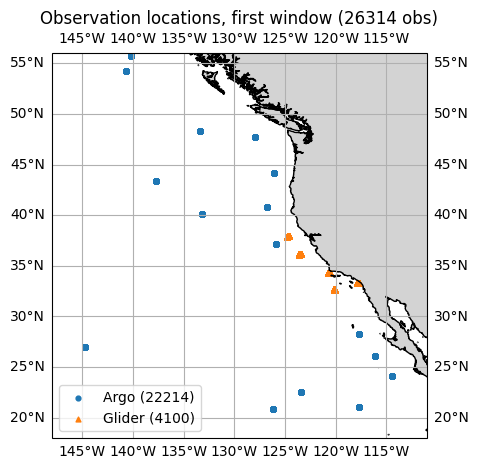

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def lon180(lon):
    """Convert 0-360 longitudes (DART convention) to -180..180 for plotting."""
    lon = np.asarray(lon, dtype=float)
    return np.where(lon > 180, lon - 360, lon)

df = obs_seq.df
print(df["type"].unique())  # check the exact type names in your file

platforms = {
    "ARGO":   {"color": "tab:blue",   "marker": "o"},
    "GLIDER": {"color": "tab:orange", "marker": "^"},
}

fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": ccrs.PlateCarree()})

for name, style in platforms.items():
    sub = df[df["type"].str.upper().str.startswith(name)]
    if len(sub) == 0:
        continue
    ax.scatter(lon180(sub["longitude"]), sub["latitude"],
               s=12, c=style["color"], marker=style["marker"],
               label=f"{name.capitalize()} ({len(sub)})",
               transform=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc="lower left")

ax.set_title(f"Observation locations, first window ({len(df)} obs)")
plt.show()

````{admonition} Try it: the vertical distribution
:class: attention

Plot a histogram of `obs_seq.df["vertical"]` for the temperature observations. 
How does the observation frequency vary by depth?
How well can the assimilation can constrain the deep ocean?
````

````{admonition} Answer
:class: dropdown

```python
obs_seq.df[obs_seq.df["type"] == "ARGO_TEMPERATURE"]["vertical"].plot.hist(bins=40)
```

Most observations sit in the upper 1000m, so the filter has little direct
information at depth. Deep corrections come only from the ensemble's own correlations
between surface and deep state, which is why localization and inflation
(Tutorial 3) matter.
````

# Recap

```{admonition} What you learned
:class: tip

- DART ingests observations as **one obs_seq file per assimilation window**. The window is
  center is YYYY-MM-DD-SSSSS in the filename `obs_seq.YYYY-MM-DD-SSSSS.out`.
- Every DART observation carries a type, a 3D location, a value, an **error variance**,
  and a time.
- `dartobsgen` converts CrocoLake observations to obs_seq files with `ObsGenConfig` +
  `CrocLakeSource` + `generate_obs_sequences`.
- Observation dates must align with the model's `RUN_STARTDATE` and assimilation cycle frequency.
- The first **analysis time** is when observations will be assimilated. 
- The assimilation frequency is the length of the window, and the center of the window is the
  analysis time, `T`. So the window runs from `T - freq/2` to T + `freq/2`
```

**Your takeaway product:** `obs/real/` in your `WORKSPACE`, 3 windows of Argo
temperature and salinity, trimmed to the Hawaii domain.

# Where to go from here?

- **[Tutorial 2: Synthetic Observations](tutorial2_synthetic_observations.ipynb)**:
  reuse these observation *locations* to sample a model state with `perfect_model_obs`.
- **[Tutorial 3: Cycling DART–CESM](tutorial3_cycling_dart_cesm.ipynb)**: assimilate
  these observations into a regional MOM6 ensemble.

# Reference Documentation

- [DART documentation on observation sequences](https://docs.dart.ucar.edu/en/latest/guide/detailed-structure-obs-seq.html)
- [dartobsgen documentation](https://crocodile-cesm.github.io/dartobsgen/) 
- [pyDARTdiags documentation](https://ncar.github.io/pyDARTdiags/) [obs_sequences](https://ncar.github.io/pyDARTdiags/userguide/working-with-obsq.html)
